In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import compute_sample_weight
import warnings
import pickle as pkl
from glob import glob
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from ibl_info.decoder_utils import (
    congregate_data,
    collapse_animal,
    individual_region_means,
    pids_per_region,
)

from ibl_info.decoder_utils import (
    plot_all_rsis,
    plot_all_decompositions,
    plot_regions_rsi,
    accuracy_per_region,
    plot_accuracies,
)
from ibl_info.decoder_utils import compute_deltas_all

In [2]:
%load_ext autoreload
%autoreload 2

In [41]:
files_stim = np.sort(
    glob("../data/generated/pairwise_decoders/stim/recomputed/goodessions/equipop_5bins/*.pkl")
)
files_choice = np.sort(
    glob("../data//generated/pairwise_decoders/choice/goodsessions/equispaced_3/*.pkl")
)

In [42]:
rsi_congruent_stim, rsi_incongruent_stim, redundancy_stim, synergy_stim, region_names_stim = (
    congregate_data(files_stim, "stim")
)

(
    rsi_congruent_choice,
    rsi_incongruent_choice,
    redundancy_choice,
    synergy_choice,
    region_names_choice,
) = congregate_data(files_choice, "choice")

In [43]:
# plot_accuracies  only works with the one that has decoding results, not the recomputed ones

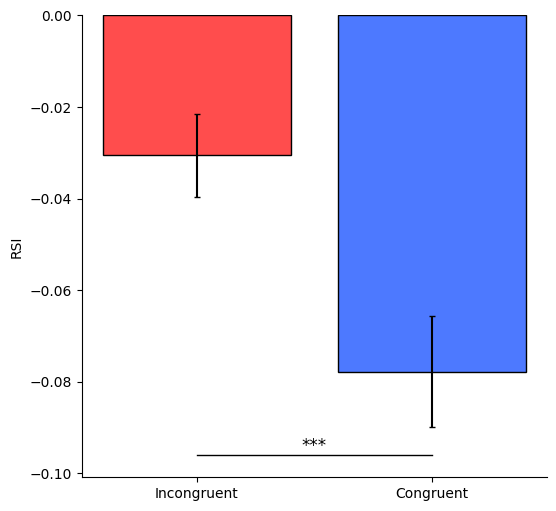

In [44]:
plot_all_rsis(rsi_congruent_choice, rsi_incongruent_choice)

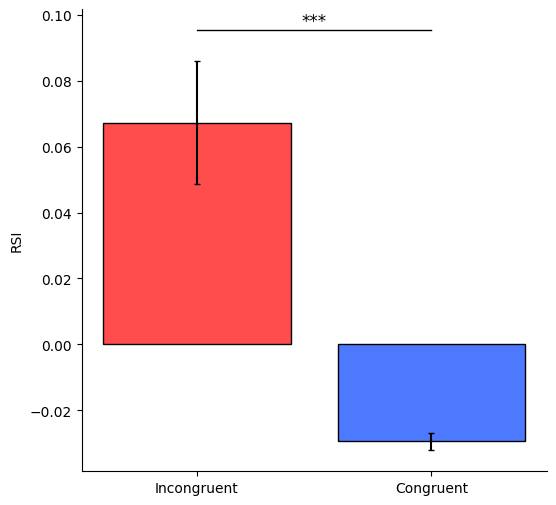

In [45]:
plot_all_rsis(rsi_congruent_stim, rsi_incongruent_stim)

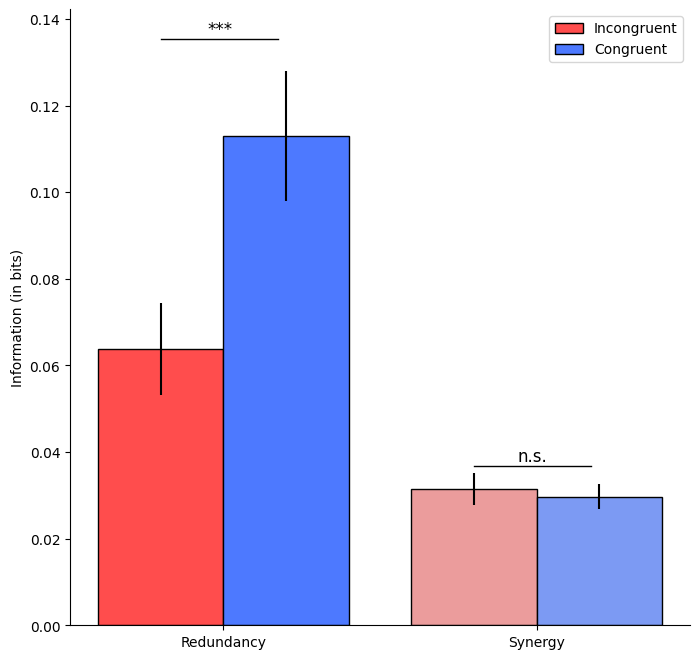

In [30]:
plot_all_decompositions(redundancy_choice, synergy_choice)

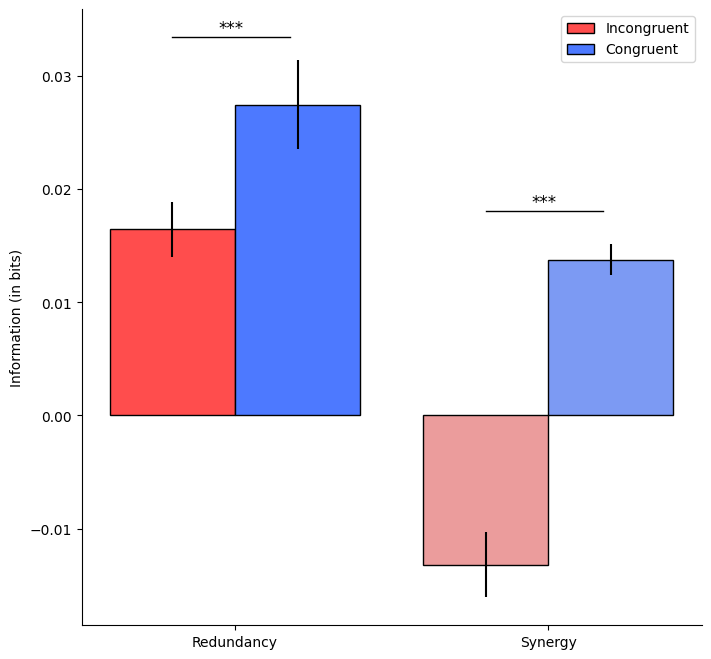

In [9]:
plot_all_decompositions(redundancy_stim, synergy_stim)

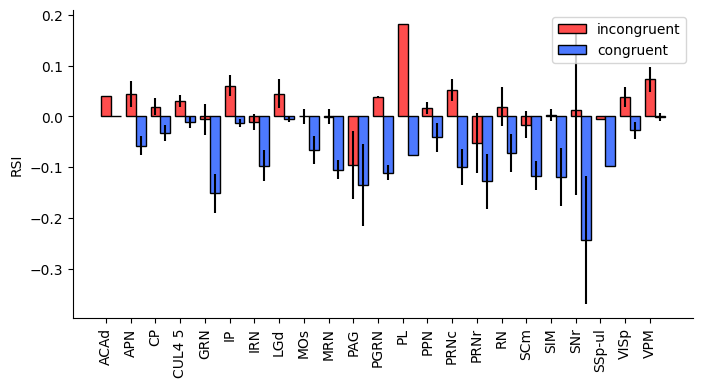

In [33]:
plot_regions_rsi(rsi_incongruent_choice, rsi_congruent_choice, region_names_choice)

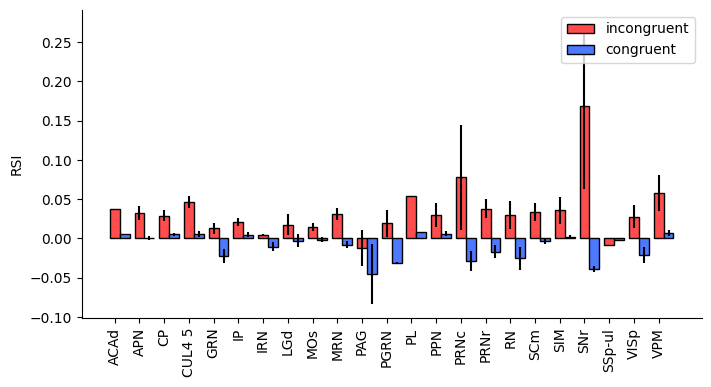

In [34]:
plot_regions_rsi(rsi_incongruent_stim, rsi_congruent_stim, region_names_stim)

In [35]:
# compute_deltas

In [36]:
# not really, we need to compute this for each animal

In [37]:
delta_congruent, delta_incongruent, region_names_delta = compute_deltas_all(
    files_choice, files_stim
)

Ey: MG, something is empty
Ey: ZI, something is empty


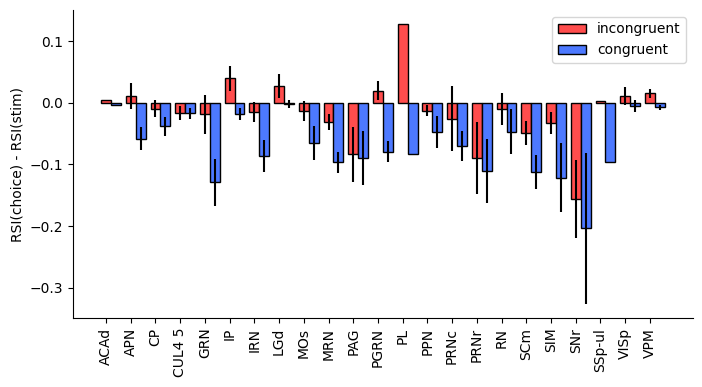

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.despine()

ax.bar(
    np.arange(len(delta_incongruent)),
    delta_incongruent[:, 0],
    yerr=delta_incongruent[:, 1],
    edgecolor="k",
    color="#FF4D4D",
    width=0.4,
    label="incongruent",
)
ax.bar(
    np.arange(len(delta_congruent)) + 0.4,
    delta_congruent[:, 0],
    yerr=delta_congruent[:, 1],
    edgecolor="k",
    color="#4D79FF",
    width=0.4,
    label="congruent",
)

ax.set_xticks(np.arange(len(region_names_delta)), region_names_delta, rotation=90)
ax.set_ylabel("RSI(choice) - RSI(stim)")
ax.legend()

In [13]:
with open(files_stim[0], "rb") as f:
    x = pkl.load(f)

In [14]:
results = x["196a2adf-ff83-49b2-823a-33f990049c2e"]["information"]

In [25]:
animal_id = "196a2adf-ff83-49b2-823a-33f990049c2e"

In [26]:
animal = x[animal_id]

In [22]:
from one.api import ONE

In [24]:
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    password="international",
    silent=True,
    username="intbrainlab",
)

In [32]:
from ibl_info.decoder_utils import return_congruent_incongruent_flags


results = animal["decoding_results"]
n_bootstraps = len(results)

congruent_flags, incongruent_flags = return_congruent_incongruent_flags(one, animal_id, "stim")

In [49]:
iteration = 4

In [50]:
output_a_all = results[iteration]["probs_A"]
output_b_all = results[iteration]["probs_B"]
target_all = results[iteration]["y_true"]

target_con = results[iteration]["y_cong"]
target_incon = results[iteration]["y_incong"]